# Paper 4 — 04 · Gemma Scope 2 SAE feature analysis (H1e)

**Gemma anchor only — corroboration.** Load pretrained Gemma Scope 2 JumpReLU residual SAEs (Gemma 3 family; no training), identify detection features (separate harm_en vs benign_en) and refusal features (separate refused vs complied prompts), and compare firing on EN vs RO harmful prompts across the bands. H1e: detection features under-fire on RO in the detection band.

**Output:** `results/gemma-3-4b/sae_features.json`.

In [1]:
%%capture
# Colab already ships consistent torch / matplotlib / pandas / scipy. We add
# only what's genuinely missing or needs a newer pin. Deliberately we do NOT
# `-U matplotlib` (upgrading it mid-session breaks the PDF backend: 'cannot
# import name FontPath'), and we do NOT install transformer-lens / nnsight /
# seaborn (unused). sae-lens is installed only in nb04 (the one place it's used).
!pip install -U \
    'transformers>=4.51' \
    'accelerate>=1.1' \
    'datasets>=3.0' \
    'scikit-learn>=1.4' \
    python-dotenv requests huggingface_hub ipywidgets pyyaml -q


In [2]:
import os, json, gc, sys, hashlib, subprocess
from pathlib import Path
from datetime import datetime
import torch

# --- Drive ---
from google.colab import drive
drive.mount("/content/drive")

# --- Secrets (Colab) -> env, so the Paper 2 judge + gated HF models work
#     end-to-end with no manual steps. Set these in Colab -> Secrets first. ---
try:
    from google.colab import userdata
    for _k in ("OPENROUTER_API_KEY", "HF_TOKEN"):
        try:
            _v = userdata.get(_k)
            if _v:
                os.environ[_k] = _v
        except Exception:
            print(f"[secrets] {_k} not set in Colab Secrets — add it if a cell needs it.")
except Exception:
    pass
if os.environ.get("HF_TOKEN"):
    from huggingface_hub import login
    login(os.environ["HF_TOKEN"], add_to_git_credential=False)

# --- Artifact root (persistent, on Drive) ---
DRIVE_ROOT  = Path("/content/drive/MyDrive/PhD/paper4-interpretability")
PAPER2_ROOT = Path("/content/drive/MyDrive/PhD/paper2-benchmark")
PAPER3_ROOT = Path("/content/drive/MyDrive/PhD/paper3-alignment")

# --- Code root: use the repo synced on Drive if present, else clone the public
#     repo to /content. Self-provisioning AND self-updating: if the /content
#     clone already exists we `git pull` it, so you always get the latest code. ---
REPO_URL = "https://github.com/robery567/rosafety-circuits.git"
if (DRIVE_ROOT / "src" / "paths.py").exists():
    CODE_ROOT = DRIVE_ROOT
else:
    CODE_ROOT = Path("/content/rosafety-circuits")
    if (CODE_ROOT / ".git").exists():
        print("Updating Paper 4 code (git pull):", CODE_ROOT)
        subprocess.run(["git", "-C", str(CODE_ROOT), "pull", "-q", "--ff-only"], check=False)
    else:
        print("Cloning Paper 4 code:", REPO_URL)
        subprocess.run(["git", "clone", "-q", REPO_URL, str(CODE_ROOT)], check=True)
print("CODE_ROOT :", CODE_ROOT)
print("DRIVE_ROOT:", DRIVE_ROOT)

# --- data dirs (Drive, persistent across sessions) ---
DATA_DIR     = DRIVE_ROOT / "data"
CONTRAST_DIR = DATA_DIR / "contrastive"
ACT_DIR      = DATA_DIR / "activations"
PROBE_DIR    = DATA_DIR / "probes"
SPLITS_DIR   = DATA_DIR / "splits"
RESULTS_DIR  = DRIVE_ROOT / "results"
FIG_DIR      = DRIVE_ROOT / "figures"
LOGS_DIR     = DRIVE_ROOT / "logs"
for d in [CONTRAST_DIR, ACT_DIR, PROBE_DIR, SPLITS_DIR, RESULTS_DIR, FIG_DIR, LOGS_DIR]:
    d.mkdir(parents=True, exist_ok=True)
CONFIG_DIR = CODE_ROOT / "configs"   # configs live in the repo, not in data/

# --- Reuse Paper 2 judge harness; Paper 4 src/ from CODE_ROOT ---
sys.path.insert(0, str(PAPER2_ROOT / "src"))      # judges.py, llm_judge.py
sys.path.insert(0, str(CODE_ROOT / "src"))         # paths, capture, probes, patching, sae_utils, contrastive, behavioral

# Drop any cached Paper 4 modules so a fresh import picks up a just-pulled
# version without needing a kernel restart.
for _m in ("paths", "capture", "probes", "patching", "sae_utils", "contrastive", "behavioral"):
    sys.modules.pop(_m, None)
from paths import savefig   # robust multi-format figure saver (PDF->cairo->SVG->PNG)

# --- A100 sanity ---
assert torch.cuda.is_available(), "Need a GPU runtime (A100 high-RAM)."
torch.backends.cuda.matmul.allow_tf32 = True
print("GPU:", torch.cuda.get_device_name(0))
print("torch:", torch.__version__)


Mounted at /content/drive


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Cloning Paper 4 code: https://github.com/robery567/rosafety-circuits.git
CODE_ROOT : /content/rosafety-circuits
DRIVE_ROOT: /content/drive/MyDrive/PhD/paper4-interpretability
GPU: NVIDIA A100-SXM4-80GB
torch: 2.11.0+cu128


## Configuration

In [3]:
# --- Anchor selection. Re-run the notebook once per anchor. ---
# All three are the exact Paper 3 anchors (probes + patching + H1d):
#   google/gemma-3-4b-it  (also the SAE anchor for H1e, via Gemma Scope 2)
#   Qwen/Qwen2.5-3B-Instruct
#   meta-llama/Llama-3.2-3B-Instruct
ANCHOR = "google/gemma-3-4b-it"

from paths import short_of, family_of
short  = short_of(ANCHOR)
family = family_of(ANCHOR)
print(f"ANCHOR : {ANCHOR}\nfamily : {family}\nshort  : {short}")


ANCHOR : google/gemma-3-4b-it
family : gemma3
short  : gemma-3-4b


In [4]:
# sae-lens (H1e only). Pin torch/torchvision/torchaudio to Colab's installed
# versions via a constraints file so pip CANNOT swap torch — swapping it
# breaks the C-extension ABI of torchvision (torchvision::nms) and torchaudio
# (undefined symbol: torch_library_impl), which transformers loads when
# resolving the multimodal Gemma-3 class. importlib.metadata reads versions
# WITHOUT importing the extensions (which may already be broken this session).
from importlib.metadata import version as _ver, PackageNotFoundError
import pathlib as _pl
_pins = []
for _p in ('torch', 'torchvision', 'torchaudio'):
    try: _pins.append(f"{_p}=={_ver(_p).split('+')[0]}")
    except PackageNotFoundError: pass
_con = '/tmp/torch_pins.txt'; _pl.Path(_con).write_text('\n'.join(_pins))
print('pinning torch stack:', _pins)
!pip install -q -c {_con} sae-lens

pinning torch stack: ['torch==2.11.0', 'torchvision==0.26.0', 'torchaudio==2.11.0']
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.1/145.1 kB 7.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 311.0/311.0 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 977.7/977.7 kB 64.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.4/52.4 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.1/274.1 kB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 236.9/236.9 kB 23.7 MB/s eta 0:00:00


In [5]:
# Consistency guard: confirm the torch C-extension stack still loads. If this
# raises, the live session is skewed (a prior unpinned install) — do
# Runtime -> Restart session and re-run nb04 from the top (the pinned
# install above then keeps Colab's matched torch/vision/audio).
import torch
try:
    import torchvision, torchaudio  # noqa: F401
    torchvision.ops.nms(torch.zeros((1, 4)), torch.zeros((1,)), 0.5)
    print(f'torch {torch.__version__} / torchvision {torchvision.__version__} / torchaudio {torchaudio.__version__}: OK')
except Exception as e:
    raise RuntimeError(
        f'torch C-extension ABI skew ({type(e).__name__}: {e}). '
        'Runtime -> Restart session, then re-run nb04 from the top.')

torch 2.11.0+cu128 / torchvision 0.26.0+cu128 / torchaudio 2.11.0+cu128: OK


In [6]:
assert short == 'gemma-3-4b', 'H1e is the SAE anchor (Gemma Scope 2 / Gemma 3).'

## 1. Load cells + behavioral labels + bands; load anchor

In [7]:
out = CONTRAST_DIR / short
def _read(n): return [json.loads(l) for l in (out/f'{n}.jsonl').read_text().splitlines() if l.strip()]
cells = {n: _read(n) for n in ['harm_en','benign_en','harm_ro','benign_ro']}
beh = {json.loads(l)['id']: json.loads(l)['label'] for l in (out/'behavioral_labels.jsonl').read_text().splitlines() if l.strip()}
bands = json.loads((RESULTS_DIR / short / 'bands.json').read_text())
band_layers = sorted(set(bands['detection'] + bands['execution']))
from transformers import AutoModelForCausalLM, AutoTokenizer
from capture import capture_assistant_prefix
tok = AutoTokenizer.from_pretrained(ANCHOR); tok.padding_side='left'
if tok.pad_token is None: tok.pad_token = tok.eos_token
model = AutoModelForCausalLM.from_pretrained(ANCHOR, torch_dtype=torch.bfloat16, device_map='cuda').eval()

config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.16M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json:   0%|          | 0.00/90.6k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

## 2. Capture residuals per cell (reuse nb02 cache if present)

In [8]:
def cap(name):
    c = ACT_DIR / short / f'{name}.pt'; c.parent.mkdir(parents=True, exist_ok=True)
    if c.exists():
        a = torch.load(c)
        if a.shape[0] == len(cells[name]): return a
    a = capture_assistant_prefix(model, tok, [r['text'] for r in cells[name]]); torch.save(a, c); return a
acts = {n: cap(n) for n in cells}
print({n: tuple(a.shape) for n, a in acts.items()})

{'harm_en': (236, 34, 2560), 'benign_en': (250, 34, 2560), 'harm_ro': (100, 34, 2560), 'benign_ro': (100, 34, 2560)}


## 3. Pre-flight: which Gemma Scope 2 SAEs exist for our band layers?

Reads the SAE coords from `configs/models.yaml` and queries the sae_lens
directory, so a missing `(width, l0)` for a band layer is caught *before*
the (slow, downloading) load loop — not halfway through it.

In [9]:
import yaml
anchor_cfg = next(m for m in yaml.safe_load((CONFIG_DIR/'models.yaml').read_text())['anchors'] if m['short']==short)
sae_cfg = anchor_cfg['sae']
RELEASE, WIDTH, L0 = sae_cfg['release'], sae_cfg['width'], sae_cfg['l0']
want = {L: f'layer_{L}_width_{WIDTH}_l0_{L0}' for L in band_layers}
print(f'release={RELEASE}  width={WIDTH}  l0={L0}  band_layers={band_layers}')
try:
    from sae_lens.toolkit.pretrained_saes_directory import get_pretrained_saes_directory
    info = get_pretrained_saes_directory().get(RELEASE)
    assert info is not None, f'{RELEASE} not in sae_lens directory (upgrade sae-lens?)'
    available = set(info.saes_map.keys())
    print(f'{len(available)} SAEs in release')
    missing = {L: sid for L, sid in want.items() if sid not in available}
    if missing:
        Lm = sorted(missing)[0]
        print('MISSING (width,l0) for band layers:', sorted(missing))
        print(f'  available at layer {Lm}:', sorted(s for s in available if s.startswith(f'layer_{Lm}_')))
        print('>> Edit configs/models.yaml sae.width / sae.l0 to an available combo, then re-run.')
    else:
        print(f'OK: all {len(band_layers)} band layers have width_{WIDTH}_l0_{L0}.')
except Exception as e:
    print('Could not query sae_lens directory:', repr(e))
    print('Fallback: the load loop below will raise on the first missing layer/combo.')

release=gemma-scope-2-4b-pt-res-all  width=16k  l0=big  band_layers=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]
Could not query sae_lens directory: ModuleNotFoundError("No module named 'sae_lens.toolkit'")
Fallback: the load loop below will raise on the first missing layer/combo.


## 4. Per-band-layer: load SAE, find detection + refusal features, compare EN vs RO firing

Detection features separate harm_en vs benign_en; refusal features separate
behaviorally-refused vs complied prompts. H1e: detection features under-fire
on RO in the detection band; refusal features fire comparably.

In [10]:
from sae_utils import load_gemma_scope_sae, encode_acts, difference_in_means_features, en_ro_firing_gap
import numpy as np
rows_en = cells['harm_en'] + cells['benign_en']
ref_mask = np.array([beh.get(r['id'])=='refuse' for r in rows_en])
per_layer = []
for L in band_layers:
    sae = load_gemma_scope_sae(L, width=WIDTH, l0=L0, release=RELEASE)
    z = {n: encode_acts(sae, acts[n][:, L]) for n in cells}
    z_en = np.concatenate([z['harm_en'], z['benign_en']], 0)
    det_feats = difference_in_means_features(z['harm_en'], z['benign_en'])
    ref_feats = difference_in_means_features(z_en[ref_mask], z_en[~ref_mask])
    gap_det = en_ro_firing_gap(z['harm_en'], z['harm_ro'], det_feats)
    gap_ref = en_ro_firing_gap(z['harm_en'], z['harm_ro'], ref_feats)
    band = 'detection' if L in bands['detection'] else 'execution'
    per_layer.append({'layer': L, 'band': band,
        'det_en_minus_ro': gap_det['en_minus_ro'], 'ref_en_minus_ro': gap_ref['en_minus_ro']})
    del sae; gc.collect(); torch.cuda.empty_cache()
    print(f"L{L} ({band}): det EN-RO firing {gap_det['en_minus_ro']:+.3f} | ref {gap_ref['en_minus_ro']:+.3f}")

config.json:   0%|          | 0.00/245 [00:00<?, ?B/s]

resid_post_all/layer_0_width_16k_l0_big/(…):   0%|          | 0.00/336M [00:00<?, ?B/s]

L0 (detection): det EN-RO firing +0.007 | ref +0.007


config.json:   0%|          | 0.00/245 [00:00<?, ?B/s]

resid_post_all/layer_1_width_16k_l0_big/(…):   0%|          | 0.00/336M [00:00<?, ?B/s]

...

resid_post_all/layer_32_width_16k_l0_big(…):   0%|          | 0.00/336M [00:00<?, ?B/s]

L32 (execution): det EN-RO firing +0.632 | ref +0.628


config.json:   0%|          | 0.00/248 [00:00<?, ?B/s]

resid_post_all/layer_33_width_16k_l0_big(…):   0%|          | 0.00/336M [00:00<?, ?B/s]

L33 (execution): det EN-RO firing +0.594 | ref +0.589


## 5. Save + plot

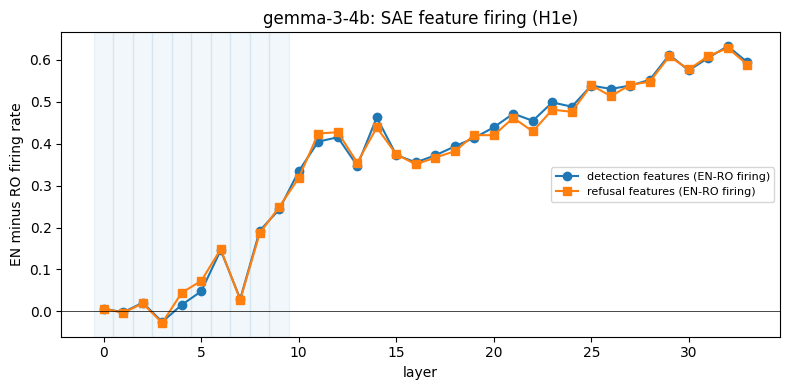

In [11]:
rs = RESULTS_DIR / short; rs.mkdir(parents=True, exist_ok=True)
(rs / 'sae_features.json').write_text(json.dumps({'anchor_model': ANCHOR, 'short': short,
    'analysis': 'sae_features', 'width': WIDTH, 'bands': bands, 'per_layer': per_layer}, indent=2))
import matplotlib.pyplot as plt
L = [p['layer'] for p in per_layer]
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(L, [p['det_en_minus_ro'] for p in per_layer], 'o-', label='detection features (EN-RO firing)')
ax.plot(L, [p['ref_en_minus_ro'] for p in per_layer], 's-', label='refusal features (EN-RO firing)')
ax.axhline(0, color='k', lw=0.5)
for b in bands['detection']: ax.axvspan(b-0.5, b+0.5, color='C0', alpha=0.06)
ax.set_xlabel('layer'); ax.set_ylabel('EN minus RO firing rate'); ax.legend(fontsize=8)
ax.set_title(f'{short}: SAE feature firing (H1e)')
fig.tight_layout(); savefig(fig, FIG_DIR / f'sae_firing_{short}.pdf'); plt.show()